# Forecasting Inflation
### **Adam Mendoza**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import os
import shap

os.environ["PYTENSOR_FLAGS"] = "cxx="
pytensor.config.cxx = ""
pytensor.config.mode = "FAST_COMPILE"

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

from statsmodels.tsa.stattools import adfuller, kpss, zivot_andrews
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from pmdarima.arima import auto_arima
from xgboost import XGBRegressor, plot_importance


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
bsp_cpi = pd.read_csv('..//data//bsp_cpibase2018_dataset.csv')
usd_php = pd.read_csv('..//data//usd_to_php.csv')
unemployment = pd.read_csv('..//data//psa_unemployment_rate.csv')
crude = pd.read_csv('..//data//global_dubai_crude.csv')

In [3]:
bsp_cpi['Date'] = pd.to_datetime(bsp_cpi['Year'].astype(str) + ' ' + bsp_cpi['Month'] + ' 1')
bsp_cpi.rename(columns={'All Items': 'CPI'}, inplace=True)
bsp_cpi = bsp_cpi[['Date', 'CPI']]
bsp_cpi.set_index('Date', inplace = True)

## **Preamble**
The change in the general level of prices in an economy is quantified through the **inflation rate**. In practice, this is often measured by determining how the **consumer price index** of a typical basket of goods vary in a span of a year. In other words

\begin{align}
I_{\mathrm{YoY}}&=\frac{\mathrm{CPI}_{t}-\mathrm{CPI}_{t-12}}{\mathrm{CPI}_{t-12}}*100\%.
\end{align}

In [4]:
inflation_rate = bsp_cpi['CPI'].pct_change(12) * 100
bsp_cpi['InflationRate'] = inflation_rate
full_inf_cpi = bsp_cpi.dropna()

full_inf_cpi.head()

,CPI,InflationRate
Date,,
1958-01-01,0.891176,6.25000
1958-02-01,0.891176,6.25000
1958-03-01,0.884623,5.46875
1958-04-01,0.884623,5.46875
1958-05-01,0.891176,6.25000


In [5]:
# USD/PHP
usd_php['Year'] = usd_php['Period'].ffill()
usd_php['Date'] = pd.to_datetime(usd_php['Year'].astype(int).astype(str) + ' ' + usd_php['Unnamed: 1'] + ' 1')
usd_php = usd_php[['Date', 'Average']].rename(columns={'Average': 'USD_PHP'})

# Unemployment
unemployment['Date'] = pd.to_datetime(unemployment['Year'].astype(str) + ' ' + unemployment['Monthly/Quarterly'] + ' 1')
unemployment['Unemployment Rate'] = pd.to_numeric(unemployment['Unemployment Rate'], errors='coerce')
unemployment = unemployment[['Date', 'Unemployment Rate']].rename(columns={'Unemployment Rate': 'UnemploymentRate'}).sort_values('Date')
unemployment['UnemploymentRate'] = unemployment['UnemploymentRate'].interpolate(method='pad', limit_area='inside')

# Crude oil
crude['Date'] = pd.to_datetime(crude['observation_date'])
crude = crude[['Date', 'POILDUBUSDM']].rename(columns={'POILDUBUSDM': 'DubaiCrude'})

# Merge all
inf_data = full_inf_cpi.merge(usd_php, on='Date', how='inner').merge(unemployment, on='Date', how='inner').merge(crude, on='Date', how='inner').sort_values('Date').reset_index(drop=True)
inf_data.set_index("Date", inplace = True)

inf_data.head()

C:\Users\PC\AppData\Local\Temp/ipykernel_8732/295856874.py:10: FutureWarning: Series.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  unemployment['UnemploymentRate'] = unemployment['UnemploymentRate'].interpolate(method='pad', limit_area='inside')


,CPI,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude
Date,,,,,
2005-01-01,60.678618,7.300116,55.766190,11.40,38.320000
2005-02-01,60.809673,7.283237,54.812842,11.40,39.673000
2005-03-01,60.940728,7.142857,54.440200,11.40,46.075652
2005-04-01,61.202839,7.233065,54.491762,8.28,47.096190
2005-05-01,61.530477,7.314286,54.341095,8.28,45.074091


In [6]:
full_inf = full_inf_cpi['InflationRate']
inf = inf_data['InflationRate']

Check if there are no missing months

In [7]:
freq = pd.infer_freq(inf.index.sort_values())
print(freq)

MS


Plot the data

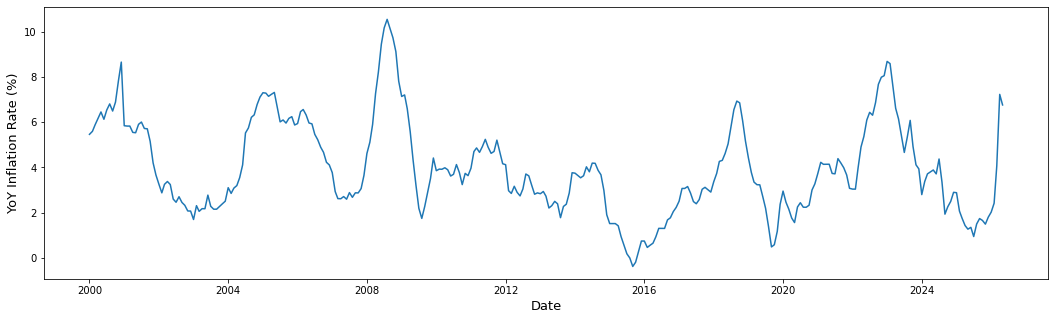

In [8]:
plt.figure(figsize=(18, 5))
plt.plot(full_inf.loc['2000':])
plt.xlabel('Date', fontsize = 13)
plt.ylabel('YoY Inflation Rate (%)', fontsize = 13)
plt.show()

The plot of the year-on-year inflation rate, which we will simply call *inflation* henceforth, exhibits alternating periods of inflation and disinflation. Several pronounced peaks and troughs are visible throughout the post-2000 segment, reflecting changes in domestic and global economic conditions.

**2004 - 2006** - Inflation increased steadily from around 2% to above 7%, coinciding with a period of rising global oil prices and the implementation of the Expanded Value-Added Tax (EVAT) law.

**2008 - 2009** - The series reached its highest level in the sample, exceeding 10% in 2008. This period overlaps with the global food and energy price surge preceding the Global Financial Crisis. Inflation subsequently declined sharply as global economic activity weakened.

**2016 - 2019** - Inflation rose from near-zero levels in 2015–2016 and peaked in 2018 before easing thereafter. This period coincided with strong domestic demand growth, infrastructure spending under the *Build, Build, Build* program, and the implementation of the *TRAIN Law*.

**2020 - 2024** - Inflation initially remained subdued during the pandemic before accelerating sharply during the post-pandemic recovery. Supply chain disruptions, higher commodity prices, and recovering demand likely contributed to the increase.

In the most recent period, inflation has risen abruptly after reaching relatively low levels in 2024–2025. This increase coincides with heightened geopolitical uncertainty and renewed volatility in global energy markets.

# I. Classical forecast: SARIMA and SARIMAX


First, we will use the full inflation data and check for stationarity. We use the Augmented Dickey-Fuller test. The null hypothesis, $H_0$, is that the series is **non-stationary**. We reject it when ADF statistic $<$ critical value.

In [9]:
adfuller(full_inf)

(-4.405822176856041,
 0.00028986881500239845,
 21,
 799,
 {'1%': -3.4385608049885876,
  '5%': -2.865164107438179,
  '10%': -2.5686998068142124},
 2559.2892887467983)

The ADF test statistic is `-4.4`. Since the test statistic is less than the critical values at $1\%$, $5\%$, and $10\%$, we reject the null hypothesis at all levels. In the Kwiatkowski-Phillips-Schmidt-Shin (KPSS), however, the null hypothesis, $H_0$, is that the series is **stationary**. We reject it when KPSS statistic $>$ critical value.

In [10]:
kpss(full_inf)

C:\Users\PC\AppData\Local\Temp/ipykernel_8732/1252803741.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss(full_inf)


(0.7668438377492122,
 0.01,
 17,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

The KPSS test statistic is `0.767`. Since the test statistic is greater than the critical values at $1\%$, $5\%$, and $10\%$, we reject the null hypothesis at all levels. Taken together, the ADF and KPSS tests provide conflicting evidence regarding stationarity. One possible explanation is the presence of structural breaks in the series. To investigate this possibility, we perform a Zivot-Andrews test. The null hypothesis is that the series contains a unit root with a single structural break.

In [11]:
zivot_andrews(full_inf.copy())

(-7.043975349159534,
 1e-05,
 {'1%': -5.27644, '5%': -4.81067, '10%': -4.56618},
 21,
 142)

The test statistic is less than all the critical values, so we reject the null hypothesis. This suggests that the data appears stationary around a structural break, suggesting that persistence may arise from regime changes rather than a true unit root. The estimated break occurs at

In [12]:
full_inf.index[142]

Timestamp('1969-11-01 00:00:00')

In [13]:
months_inc = 24

inf_train = full_inf[:-months_inc]
inf_test = full_inf[-months_inc:]

sarima_model = auto_arima(inf_train, seasonal=True, m=12) 
print(sarima_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  797
Model:             SARIMAX(1, 1, 2)x(0, 0, [1], 12)   Log Likelihood               -1181.061
Date:                              Tue, 16 Jun 2026   AIC                           2372.122
Time:                                      18:05:17   BIC                           2395.520
Sample:                                  01-01-1958   HQIC                          2381.113
                                       - 05-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8824      0.022     40.104      0.000       0.839       0.926
ma.L1         -0.53

We compare the SARIMA forecast with naive forecasts.

In [14]:
sarima_forecast = pd.Series(sarima_model.predict(n_periods=len(inf_test)), index=inf_test.index)
naive_forecast = pd.Series(np.repeat(inf_train.iloc[-1], len(inf_test)), index=inf_test.index)
seasonal_naive_forecast = full_inf.shift(12).loc[inf_test.index]

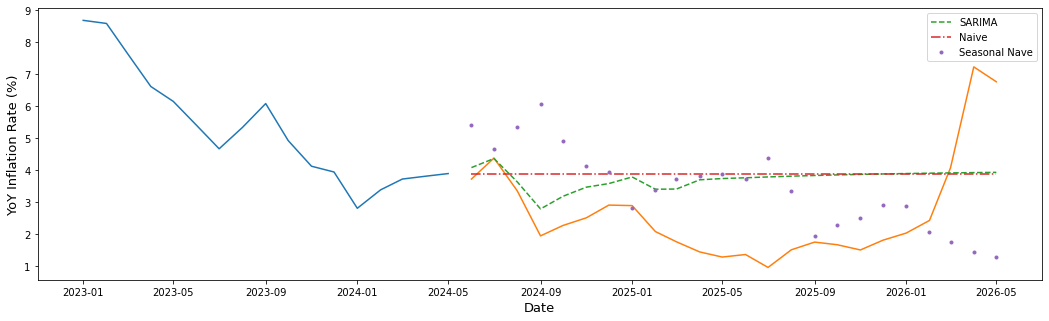

In [15]:
start_date = '2023-01-01'

plt.figure(figsize=(18, 5))
plt.plot(inf_train.loc[start_date:])
plt.plot(inf_test.loc[start_date:])
plt.plot(sarima_forecast.loc[start_date:], '--', label = 'SARIMA')
plt.plot(naive_forecast.loc[start_date:], '-.', label = 'Naive')
plt.plot(seasonal_naive_forecast.loc[start_date:], '.', label = 'Seasonal Nave')

plt.xlabel('Date', fontsize = 13)
plt.ylabel('YoY Inflation Rate (%)', fontsize = 13)
plt.legend()
plt.show()

In [16]:
comp_forecasts = [sarima_forecast, naive_forecast, seasonal_naive_forecast]
rmse_list = []
for forecast in comp_forecasts:
    mae = mean_absolute_error(inf_test, forecast)
    rmse = np.sqrt(mean_squared_error(inf_test, forecast))
    rmse_list.append(rmse)

print('The RMSE for SARIMA is {:.2f}'.format(rmse_list[0]))
print('The RMSE for Naive is {:.2f}'.format(rmse_list[1]))
print('The RMSE for Seasonal Naive is {:.2f}'.format(rmse_list[2]))

The RMSE for SARIMA is 1.85
The RMSE for Naive is 2.01
The RMSE for Seasonal Naive is 2.47


In [17]:
horizons = [1, 2, 6, 12, 24]

results = []

for h in horizons:
    inf_train = full_inf.iloc[:-h]
    inf_test = full_inf.iloc[-h:]

    sarima_model = auto_arima(inf_train, seasonal=True, m=12, suppress_warnings=True)
    sarima_forecast = pd.Series(sarima_model.predict(n_periods=h), index=inf_test.index)
    naive_forecast = pd.Series(np.repeat(inf_train.iloc[-1], h), index=inf_test.index)
    seasonal_naive_forecast = full_inf.shift(12).loc[inf_test.index]

    sarima_rmse = np.sqrt(mean_squared_error(inf_test, sarima_forecast))
    naive_rmse = np.sqrt(mean_squared_error(inf_test, naive_forecast))
    seasonal_naive_rmse = np.sqrt(mean_squared_error(inf_test, seasonal_naive_forecast))

    results.append({
        "Forecast Horizon": h,
        "SARIMA RMSE": sarima_rmse,
        "Naive RMSE": naive_rmse,
        "Seasonal Naive RMSE": seasonal_naive_rmse
    })

In [18]:
rmse_table = pd.DataFrame(results)
rmse_table

,Forecast Horizon,SARIMA RMSE,Naive RMSE,Seasonal Naive RMSE
0,1,1.657588,0.466016,5.487121
1,2,1.760592,2.934423,5.642010
2,6,2.929000,3.376615,3.442484
3,12,2.052118,2.518216,2.787378
4,24,1.852536,2.011048,2.466339


SARIMA outperforms naive forecasts for 2 to 24 month horizons. We will now deploy for a forecast for the next six months.

In [19]:
sarima_model_final = auto_arima(full_inf, seasonal=True, m=12, suppress_warnings=True)
sarima_forecast, conf_int = sarima_model_final.predict(n_periods=6, return_conf_int=True)
sarima_forecast = pd.Series(sarima_forecast)

forecast_index = pd.date_range(start=full_inf.index[-1] + pd.offsets.MonthBegin(1), periods=6, freq="MS")
forecast_df = pd.DataFrame({"Forecast": sarima_forecast, "Lower95": conf_int[:, 0], "Upper95": conf_int[:, 1]}, index=forecast_index)
forecast_df["95% PI"] = forecast_df.apply(lambda x: f"[{x['Lower95']:.2f}, {x['Upper95']:.2f}]", axis=1)
print(forecast_df[["Forecast", "95% PI"]])

            Forecast         95% PI
2026-06-01  7.036636   [4.98, 9.09]
2026-07-01  7.390334  [3.95, 10.83]
2026-08-01  7.378207  [2.72, 12.04]
2026-09-01  7.795006  [1.98, 13.61]
2026-10-01  8.106122  [1.18, 15.03]
2026-11-01  8.447115  [0.44, 16.46]


The forecasted inflation next month is $7\%$ and will steadily increase to $8.45\%$ come November. We now do SARIMAX, where we use exogenous variables such as the USD to PHP exchange rate, unemployment rate, and the price of a barrel of Dubai Crude Oil in USD.

In [20]:
months_inc = 24

exog = inf_data[['USD_PHP', 'UnemploymentRate', 'DubaiCrude']]

inf_train = inf[:-months_inc]
inf_test = inf[-months_inc:]

exog_train = exog[:-months_inc]
exog_test = exog[-months_inc:]

In [21]:
sarimax_model = auto_arima(inf_train, X = exog_train, seasonal=True, m=12) 
print(sarimax_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  233
Model:             SARIMAX(1, 1, 0)x(0, 0, [1], 12)   Log Likelihood                 -78.191
Date:                              Tue, 16 Jun 2026   AIC                            168.382
Time:                                      18:08:54   BIC                            189.062
Sample:                                  01-01-2005   HQIC                           176.722
                                       - 05-01-2024                                         
Covariance Type:                                opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
USD_PHP              0.0163      0.024      0.686      0.493      -0.030       0.063
U

The p-values of each exogenous variable is much greater than `0.05`. Despite their economic motivations for being incorporated in the model, the results indicate that none of the considered variables are significant. We proceed with the forecast.

In [22]:
sarimax_forecast = pd.Series(sarimax_model.predict(n_periods=len(inf_test), X=exog_test), index=inf_test.index)
naive_forecast = pd.Series(np.repeat(inf_train.iloc[-1], len(inf_test)), index=inf_test.index)
seasonal_naive_forecast = inf.shift(12).loc[inf_test.index]

In [23]:
comp_forecasts = [sarimax_forecast, naive_forecast, seasonal_naive_forecast]
rmse_list = []
for forecast in comp_forecasts:
    mae = mean_absolute_error(inf_test, forecast)
    rmse = np.sqrt(mean_squared_error(inf_test, forecast))
    rmse_list.append(rmse)

print('The RMSE for SARIMAX is {:.2f}'.format(rmse_list[0]))
print('The RMSE for Naive is {:.2f}'.format(rmse_list[1]))
print('The RMSE for Seasonal Naive is {:.2f}'.format(rmse_list[2]))

The RMSE for SARIMAX is 1.98
The RMSE for Naive is 2.01
The RMSE for Seasonal Naive is 2.47


We got a larger RMSE for SARIMAX than SARIMA. There are two possible reasons: first, pure SARIMA has a larger sample size for the inflation rate data and may capture behaviors that are observable on longer terms. Second, having exogenous variables contributing little useful information still means more parameters for the model to estimate, leading to noise fitting and may worsen forecast. We now proceed.

In [24]:
sarima_usdphp = auto_arima(exog['USD_PHP'], seasonal=True) 
sarima_unemployment = auto_arima(exog['UnemploymentRate'], seasonal=True)
sarima_dubai = auto_arima(exog['DubaiCrude'], seasonal=True)

future_usdphp = pd.Series(sarima_usdphp.predict(n_periods=6), name = exog['USD_PHP'].name)
future_unemployment = pd.Series(sarima_unemployment.predict(n_periods=6), name = exog['UnemploymentRate'].name)
future_dubai = pd.Series(sarima_dubai.predict(n_periods=6), name = exog['DubaiCrude'].name)

future_exog = pd.concat([future_usdphp, future_unemployment, future_dubai], axis = 1)
full_exog = pd.concat([exog, future_exog])

sarima_model_final = auto_arima(inf, X = exog, seasonal=True, m=12, suppress_warnings=True)
sarima_forecast, conf_int = sarima_model_final.predict(n_periods=6, X = future_exog, return_conf_int= True)
sarima_forecast = pd.Series(sarima_forecast)

forecast_index = pd.date_range(start=full_inf.index[-1] + pd.offsets.MonthBegin(1), periods=6, freq="MS")
forecast_df = pd.DataFrame({"Forecast": sarima_forecast, "Lower95": conf_int[:, 0], "Upper95": conf_int[:, 1]}, index=forecast_index)
forecast_df["95% PI"] = forecast_df.apply(lambda x: f"[{x['Lower95']:.2f}, {x['Upper95']:.2f}]", axis=1)
print(forecast_df[["Forecast", "95% PI"]])

            Forecast        95% PI
2026-06-01  5.995891  [5.19, 6.80]
2026-07-01  6.045590  [4.60, 7.50]
2026-08-01  6.033223  [4.15, 7.92]
2026-09-01  6.307850  [4.07, 8.54]
2026-10-01  6.293417  [3.75, 8.83]
2026-11-01  6.351398  [3.54, 9.16]


SARIMAX predicts $6\%$ inflation rate for next month, increasing to $6.35\%$ in the next six months. Note that the uncertainty here does not incorporate ones derived from predicting future exogenous variable values.

## II. XGBoost

In [25]:
full_inf = bsp_cpi.dropna().copy()

full_inf["month"] = full_inf.index.month   
full_inf["quarter"] = full_inf.index.quarter
full_inf["year"] = full_inf.index.year

full_inf["month_sin"] = np.sin(2 * np.pi * full_inf["month"] / 12)
full_inf["month_cos"] = np.cos(2 * np.pi * full_inf["month"] / 12)

for lag in [1, 2, 3, 6, 12, 24]:
    full_inf[f"inf_lag_{lag}"] = full_inf["InflationRate"].shift(lag)

for lag in [1, 2, 3, 6, 12, 24]:
    full_inf[f"cpi_lag_{lag}"] = full_inf["CPI"].shift(lag)

for window in [3, 6, 12]:
    full_inf[f"inf_roll_mean_{window}"] = full_inf["InflationRate"].shift(1).rolling(window).mean()
    full_inf[f"inf_roll_std_{window}"] = full_inf["InflationRate"].shift(1).rolling(window).std()

full_inf["cpi_mom"] = full_inf["CPI"].pct_change(1) * 100
full_inf["cpi_qoq"] = full_inf["CPI"].pct_change(3) * 100
full_inf["cpi_hy"] = full_inf["CPI"].pct_change(6) * 100

full_inf["target"] = full_inf["InflationRate"].shift(-1)

feature_cols = [
    "month_sin", "month_cos",
    "inf_lag_1", "inf_lag_2", "inf_lag_3", "inf_lag_6", "inf_lag_12", "inf_lag_24",
    "cpi_lag_1", "cpi_lag_2", "cpi_lag_3", "cpi_lag_6", "cpi_lag_12", "cpi_lag_24",
    "inf_roll_mean_3", "inf_roll_mean_6", "inf_roll_mean_12",
    "inf_roll_std_3", "inf_roll_std_6", "inf_roll_std_12",
    "cpi_mom", "cpi_qoq", "cpi_hy"
    ]


forecast_X = full_inf[feature_cols].iloc[[-1]]

train_df = full_inf.dropna()

X = train_df[feature_cols]
y = train_df["target"]

test_horizon = 24

X_train = X.iloc[:-test_horizon]
X_test = X.iloc[-test_horizon:]

y_train = y.iloc[:-test_horizon]
y_test = y.iloc[-test_horizon:]

In [26]:
param_grid = {
    "n_estimators": [*range(50, 1000, 50)],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.1, 1, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=5)
base_model = XGBRegressor(objective="reg:squarederror", random_state=420)
search = RandomizedSearchCV(base_model, param_distributions=param_grid, n_iter=250, scoring="neg_root_mean_squared_error", cv=tscv, random_state=420, n_jobs=-1)

search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print(f"Best CV RMSE: {-search.best_score_:.3f}")

Best Parameters:
{'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.6}
Best CV RMSE: 2.793


Test RMSE: 0.963


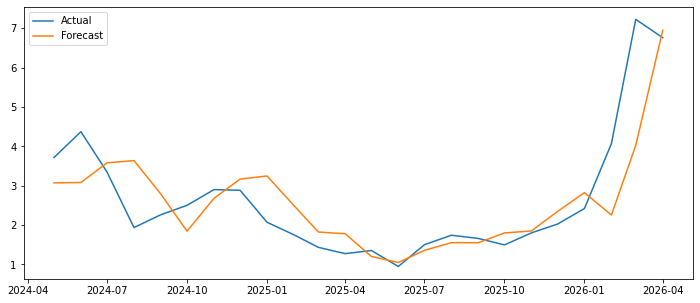

In [27]:
model = search.best_estimator_

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test RMSE: {rmse:.3f}")

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Forecast")
plt.legend()
plt.show()

In [28]:
final_model = XGBRegressor(**search.best_params_, objective="reg:squarederror", random_state=420)
final_model.fit(X, y, verbose=False)

forecast = final_model.predict(forecast_X)
print(f"Inflation next month: {forecast[0]:.2f}%")

Inflation next month: 7.30%


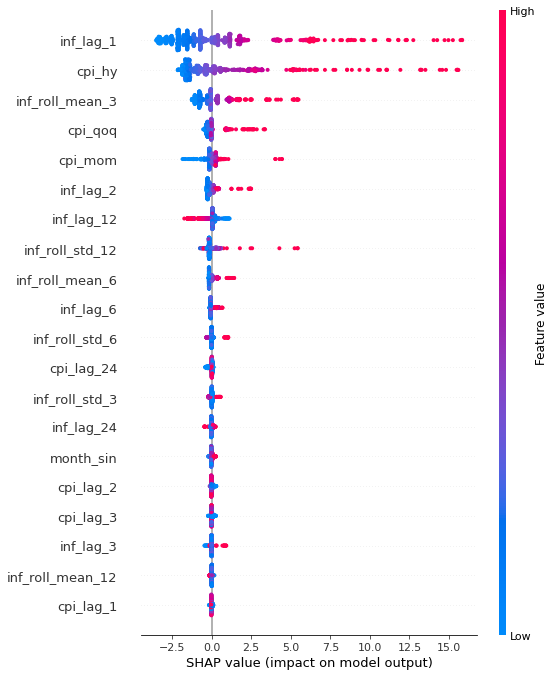

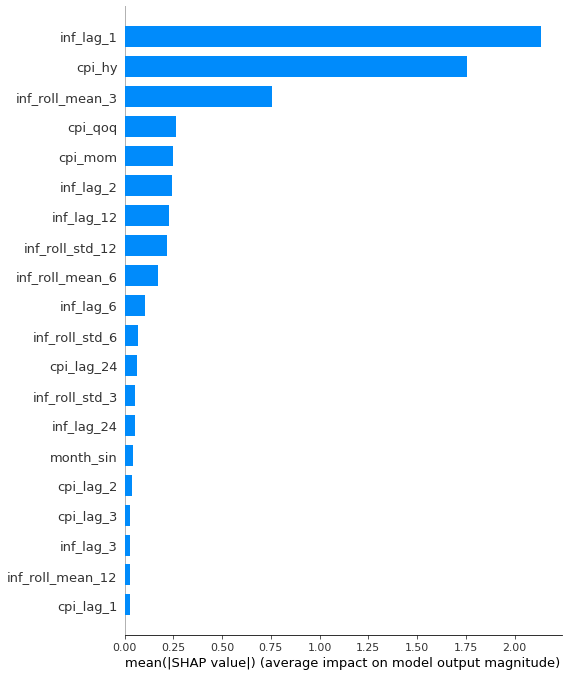

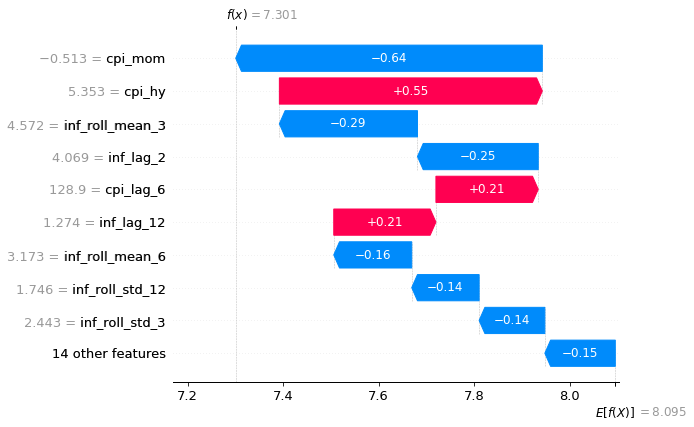

In [29]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)
shap.summary_plot(shap_values, X, plot_type="bar")
last_obs = forecast_X.iloc[[0]]

shap.waterfall_plot(shap.Explanation(values=explainer.shap_values(last_obs)[0], base_values=explainer.expected_value, data=last_obs.iloc[0], feature_names=last_obs.columns))
plt.show()

If we focus on the waterfall plot, the model would normally predict an inflation rate of $8.095\%$. However, recent inflationary dynamics pulled the forecast down to $7.301\%$. Suppose we add the exogenous variables.

In [30]:
lags = [1, 2, 3, 6, 12, 24]

inf_data["month"] = inf_data.index.month   
inf_data["quarter"] = inf_data.index.quarter
inf_data["year"] = inf_data.index.year

inf_data["month_sin"] = np.sin(2 * np.pi * inf_data["month"] / 12)
inf_data["month_cos"] = np.cos(2 * np.pi * inf_data["month"] / 12)

lag_features = {
    "inf": "InflationRate",
    "cpi": "CPI",
    "usd_php": "USD_PHP",
    "unemployment": "UnemploymentRate",
    "dubai": "DubaiCrude"
}

for prefix, col in lag_features.items():
    for lag in lags:
        inf_data[f"{prefix}_lag_{lag}"] = inf_data[col].shift(lag)

for window in [3, 6, 12]:
    inf_data[f"inf_roll_mean_{window}"] = inf_data["InflationRate"].shift(1).rolling(window).mean()
    inf_data[f"inf_roll_std_{window}"] = inf_data["InflationRate"].shift(1).rolling(window).std()

inf_data["cpi_mom"] = inf_data["CPI"].pct_change(1) * 100
inf_data["cpi_qoq"] = inf_data["CPI"].pct_change(3) * 100
inf_data["cpi_hy"] = inf_data["CPI"].pct_change(6) * 100

inf_data["target"] = inf_data["InflationRate"].shift(-1)

feature_cols = [
    "month_sin", "month_cos",
    "inf_lag_1", "inf_lag_2", "inf_lag_3", "inf_lag_6", "inf_lag_12", "inf_lag_24",
    "cpi_lag_1", "cpi_lag_2", "cpi_lag_3", "cpi_lag_6", "cpi_lag_12", "cpi_lag_24",
    "inf_roll_mean_3", "inf_roll_mean_6", "inf_roll_mean_12",
    "inf_roll_std_3", "inf_roll_std_6", "inf_roll_std_12",
    "cpi_mom", "cpi_qoq", "cpi_hy",
    "usd_php_lag_1", "usd_php_lag_2", "usd_php_lag_3", "usd_php_lag_6", "usd_php_lag_12", "usd_php_lag_24",
    "unemployment_lag_1", "unemployment_lag_2", "unemployment_lag_3", "unemployment_lag_6", "unemployment_lag_12", "unemployment_lag_24",
    "dubai_lag_1", "dubai_lag_2", "dubai_lag_3", "dubai_lag_6", "dubai_lag_12", "dubai_lag_24"
    ]

forecast_X = inf_data[feature_cols].iloc[[-1]]

train_df = inf_data.dropna()

X = train_df[feature_cols]
y = train_df["target"]

test_horizon = 24

X_train = X.iloc[:-test_horizon]
X_test = X.iloc[-test_horizon:]

y_train = y.iloc[:-test_horizon]
y_test = y.iloc[-test_horizon:]

In [31]:
param_grid = {
    "n_estimators": [*range(50, 1000, 50)],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.1, 1, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=5)
base_model = XGBRegressor(objective="reg:squarederror", random_state=420)
search = RandomizedSearchCV(base_model, param_distributions=param_grid, n_iter=250, scoring="neg_root_mean_squared_error", cv=tscv, random_state=420, n_jobs=-1)

search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print(f"Best CV RMSE: {-search.best_score_:.3f}")

Best Parameters:
{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0.01, 'n_estimators': 150, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.8}
Best CV RMSE: 1.272


Test RMSE: 1.081


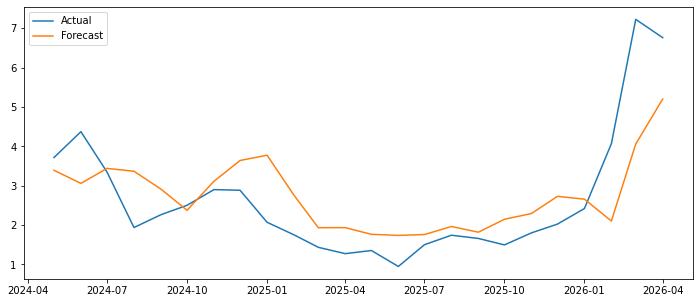

In [32]:
model = search.best_estimator_

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test RMSE: {rmse:.3f}")

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Forecast")
plt.legend()
plt.show()

In [33]:
final_model = XGBRegressor(**search.best_params_, objective="reg:squarederror", random_state=420)
final_model.fit(X, y, verbose=False)

forecast = final_model.predict(forecast_X)
print(f"Inflation next month: {forecast[0]:.2f}%")

Inflation next month: 7.53%


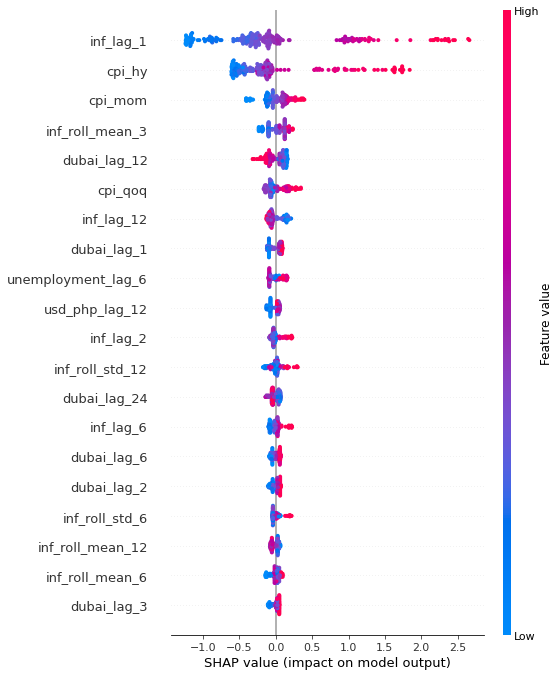

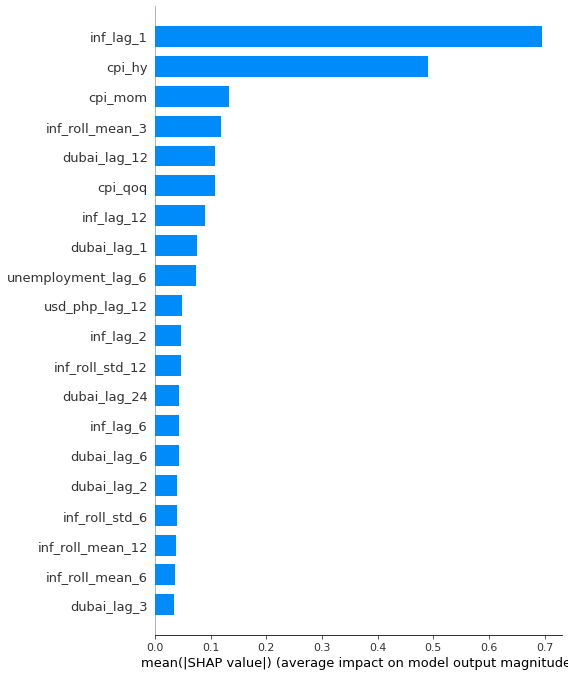

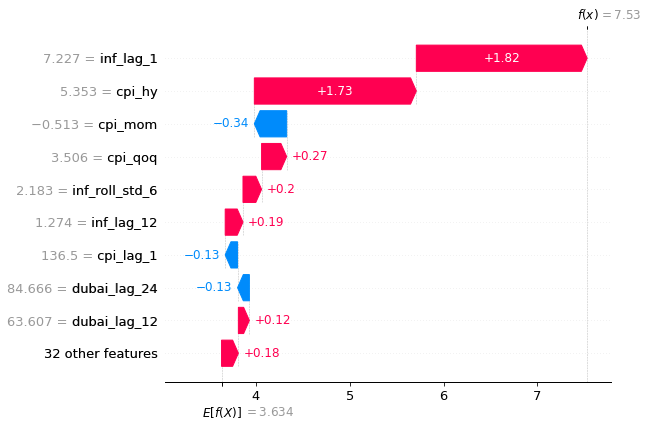

In [34]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)
shap.summary_plot(shap_values, X, plot_type="bar")
last_obs = forecast_X.iloc[[0]]

shap.waterfall_plot(shap.Explanation(values=explainer.shap_values(last_obs)[0], base_values=explainer.expected_value, data=last_obs.iloc[0], feature_names=last_obs.columns))
plt.show()

The model initially predicts $3.634\%$ inflation rate but current inflationary trends as well as crude oil price and unemployment rate pushes the prediction to a higher $7.53\%$.

## III. Bayesian Autoregressive Model

In [35]:
bayes_df = full_inf[['InflationRate']].copy()

for lag in range(1, 13):
    bayes_df[f'lag_{lag}'] = bayes_df['InflationRate'].shift(lag)

bayes_df = bayes_df.dropna()

months_inc = 24

train_df = bayes_df.iloc[:-months_inc]
test_df = bayes_df.iloc[-months_inc:]

X_train = train_df[[f'lag_{i}' for i in range(1, 13)]].values
y_train = train_df['InflationRate'].values

X_test = test_df[[f'lag_{i}' for i in range(1, 13)]].values
y_test = test_df['InflationRate'].values

with pm.Model() as inflation_model:

    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=5, shape=12)
    sigma = pm.HalfNormal("sigma", sigma=5)

    mu = alpha + pm.math.dot(X_train, beta)

    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=y_train)

    trace = pm.sample(draws=4000, tune=2000, chains=4, target_accept=0.95, cores=4, random_seed=420)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 1603 seconds.


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     0.334  0.074   0.192    0.471      0.001      0.0   18169.0   
beta[0]   1.301  0.036   1.235    1.371      0.000      0.0   11861.0   
beta[1]  -0.225  0.060  -0.332   -0.110      0.001      0.0   11042.0   
beta[2]  -0.058  0.060  -0.171    0.053      0.001      0.0   13078.0   
beta[3]  -0.009  0.060  -0.118    0.104      0.001      0.0   13064.0   
beta[4]  -0.011  0.059  -0.125    0.099      0.000      0.0   14327.0   
beta[5]   0.014  0.060  -0.100    0.125      0.001      0.0   14297.0   
beta[6]   0.039  0.060  -0.074    0.153      0.001      0.0   14319.0   
beta[7]  -0.047  0.060  -0.161    0.062      0.001      0.0   14111.0   
beta[8]  -0.038  0.060  -0.150    0.072      0.001      0.0   14083.0   
beta[9]  -0.024  0.060  -0.142    0.084      0.001      0.0   13974.0   
beta[10] -0.047  0.059  -0.159    0.064      0.001      0.0   12073.0   
beta[11]  0.064  0.036  -0.005    0.131      0.000 

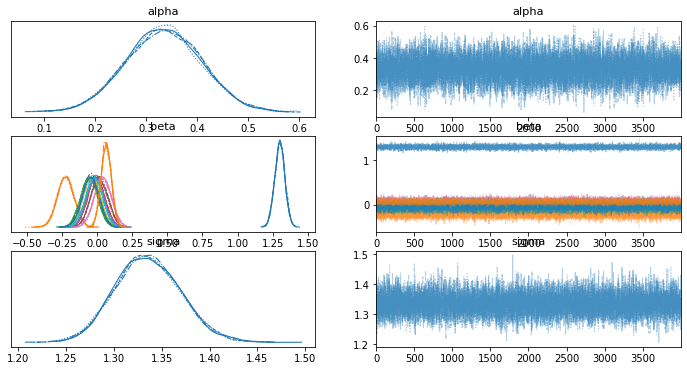

In [36]:
print(az.summary(trace))

az.plot_trace(trace)
plt.show()

Sampling: [obs]


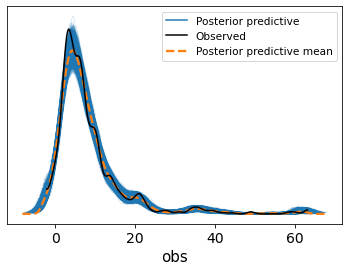

In [37]:
with inflation_model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=420)

az.plot_ppc(ppc)
plt.show()

Bayesian AR MAE: 0.577
Bayesian AR RMSE: 0.839


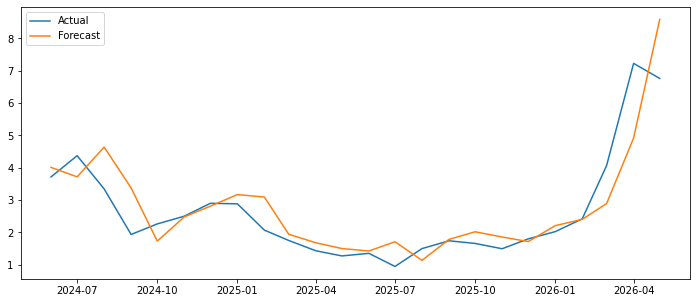

In [38]:
alpha_samples = trace.posterior["alpha"].values.flatten()
beta_samples = trace.posterior["beta"].values.reshape(-1, 12)

bayes_preds = []

for row in X_test:
    pred_draws = alpha_samples + np.sum(beta_samples * row, axis=1)
    bayes_preds.append(pred_draws.mean())

bayes_preds = np.array(bayes_preds)

mae = mean_absolute_error(y_test, bayes_preds)
rmse = np.sqrt(mean_squared_error(y_test, bayes_preds))

print(f"Bayesian AR MAE: {mae:.3f}")
print(f"Bayesian AR RMSE: {rmse:.3f}")

plt.figure(figsize=(12, 5))
plt.plot(test_df.index, y_test, label="Actual")
plt.plot(test_df.index, bayes_preds, label="Forecast")
plt.legend()
plt.show()


In [39]:
X_full = bayes_df[[f'lag_{i}' for i in range(1, 13)]].values
y_full = bayes_df['InflationRate'].values

with pm.Model() as inflation_model_final:

    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=5, shape=12)
    sigma = pm.HalfNormal("sigma", sigma=5)

    mu = alpha + pm.math.dot(X_full, beta)

    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=y_full)

    final_trace = pm.sample(draws=4000, tune=2000, chains=4, target_accept=0.95, cores=4, random_seed=420)

latest_lags = full_inf['InflationRate'].iloc[-12:].to_numpy()[::-1]

alpha_samples = final_trace.posterior["alpha"].values.flatten()
beta_samples = final_trace.posterior["beta"].values.reshape(-1, 12)
sigma_samples = final_trace.posterior["sigma"].values.flatten()

forecast_draws = alpha_samples + np.sum(beta_samples * latest_lags, axis=1) + np.random.normal(0, sigma_samples)

forecast_mean = forecast_draws.mean()
forecast_median = np.median(forecast_draws)
forecast_lower = np.percentile(forecast_draws, 2.5)
forecast_upper = np.percentile(forecast_draws, 97.5)

print(f"Next-month inflation forecast: {forecast_mean:.2f}%")
print(f"Median forecast: {forecast_median:.2f}%")
print(f"95% credible interval: [{forecast_lower:.2f}%, {forecast_upper:.2f}%]")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 1769 seconds.


Next-month inflation forecast: 7.16%
Median forecast: 7.16%
95% credible interval: [4.56%, 9.75%]


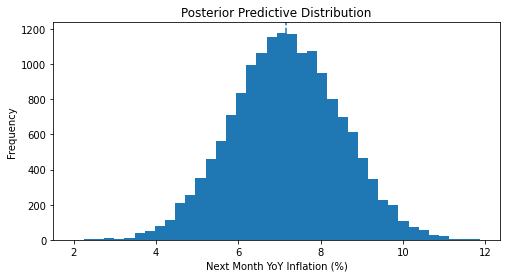

In [40]:
plt.figure(figsize=(8, 4))
plt.hist(forecast_draws, bins=40)
plt.axvline(forecast_mean, linestyle='--')
plt.xlabel('Next Month YoY Inflation (%)')
plt.ylabel('Frequency')
plt.title('Posterior Predictive Distribution')
plt.show()

## **Summary**
| Model                           | Inflation Forecast (%) | Test RMSE |
|---------------------------------|------------------------|-----------|
| SARIMA                          | 7.04                   | 1.85      |
| SARIMAX                         | 6.00                   | 1.98      |
| XGBoost                         | 7.30                   | 0.96      |
| XGBoost w/ Exogenous Variables  | 7.53                   | 1.08      |
| Bayesian Autoregressive Model   | 7.16                   | 0.84      |